In [3]:
# ============================================================
# EMPLOYEE ATTRITION — STEP 1: Data Loading & Exploration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

# ── 1. Load Data ─────────────────────────────────────────────
train = pd.read_csv(r"C:\Users\deept\Downloads\train.csv")
test  = pd.read_csv(r"C:\Users\deept\Downloads\test.csv")

print(f"Train shape : {train.shape}")   # rows × columns
print(f"Test  shape : {test.shape}")

# ── 2. Quick look ────────────────────────────────────────────
train.head(5)

Train shape : (59598, 24)
Test  shape : (14900, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
# ── 3. Column types & non-null counts ───────────────────────
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [5]:
# ── 4. Statistical summary ──────────────────────────────────
train.describe(include="all").T   # .T = transpose so it fits the screen

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,NaN,NaN,NaN,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,NaN,NaN,NaN,38.565875,12.079673,18.0,28.0,39.0,49.0,59.0
Gender,59598,2,Male,32739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years at Company,59598.0,NaN,NaN,NaN,15.753901,11.245981,1.0,7.0,13.0,23.0,51.0
Job Role,59598,5,Technology,15507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Income,59598.0,NaN,NaN,NaN,7302.397983,2151.457423,1316.0,5658.0,7354.0,8880.0,16149.0
Work-Life Balance,59598,4,Good,22528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Satisfaction,59598,4,High,29779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance Rating,59598,4,Average,35810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Promotions,59598.0,NaN,NaN,NaN,0.832578,0.994991,0.0,0.0,1.0,2.0,4.0


In [6]:
# ── 5. Missing values ────────────────────────────────────────
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct %": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Pct %", ascending=False)

print("=== Columns with missing values ===")
print(missing_df if not missing_df.empty else "✅ No missing values in train!")

=== Columns with missing values ===
✅ No missing values in train!


=== Target: Attrition ===
           Count  Pct %
Attrition              
Stayed     31260   52.5
Left       28338   47.5


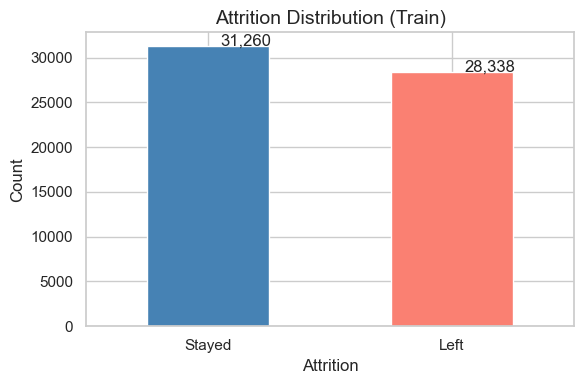

In [7]:
# ── 6. Target distribution ──────────────────────────────────
target_counts = train["Attrition"].value_counts()
target_pct    = train["Attrition"].value_counts(normalize=True) * 100

print("=== Target: Attrition ===")
print(pd.DataFrame({"Count": target_counts, "Pct %": target_pct.round(1)}))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Attrition Distribution (Train)", fontsize=14)
ax.set_ylabel("Count")
ax.set_xticklabels(["Stayed", "Left"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.3, p.get_height() + 100))
plt.tight_layout()
plt.savefig("attrition_distribution.png", dpi=150)
plt.show()

Numeric columns: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']


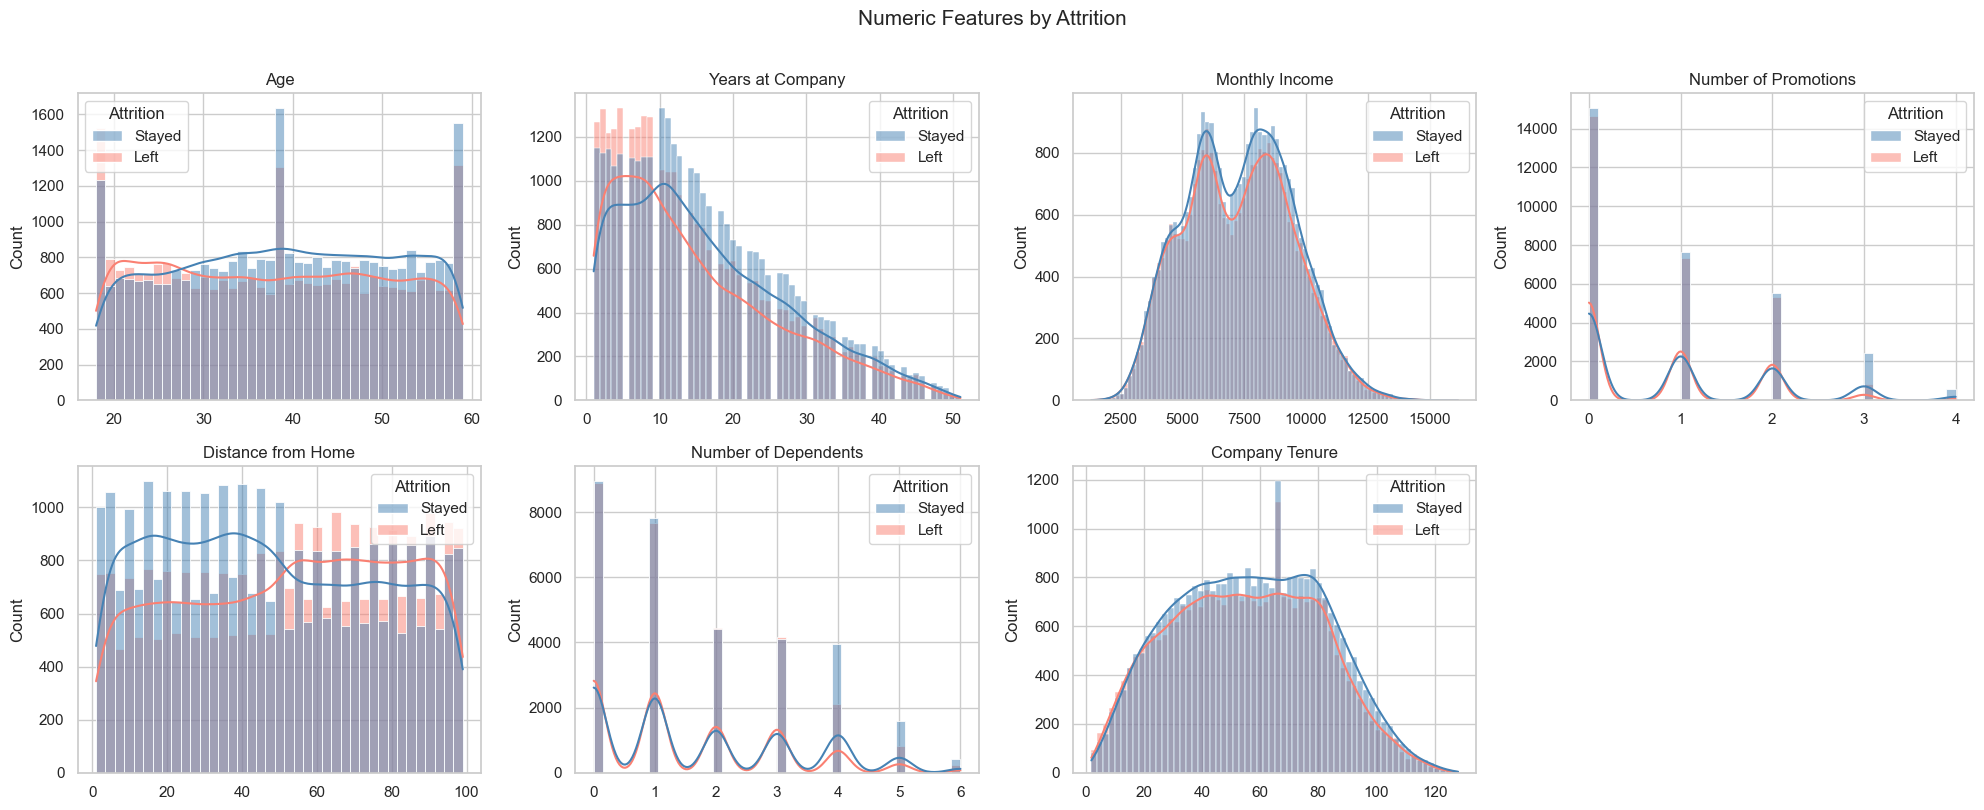

In [9]:
# ── 7. Numeric features overview ────────────────────────────
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Employee ID")
print("Numeric columns:", num_cols)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))  # 2×4 = 8 slots for 7 columns
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, hue="Attrition", kde=True,
                 ax=axes[i], palette={"Stayed": "steelblue", "Left": "salmon"})
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide the unused 8th subplot
axes[len(num_cols)].set_visible(False)

plt.suptitle("Numeric Features by Attrition", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("numeric_distributions.png", dpi=150)
plt.show()

Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


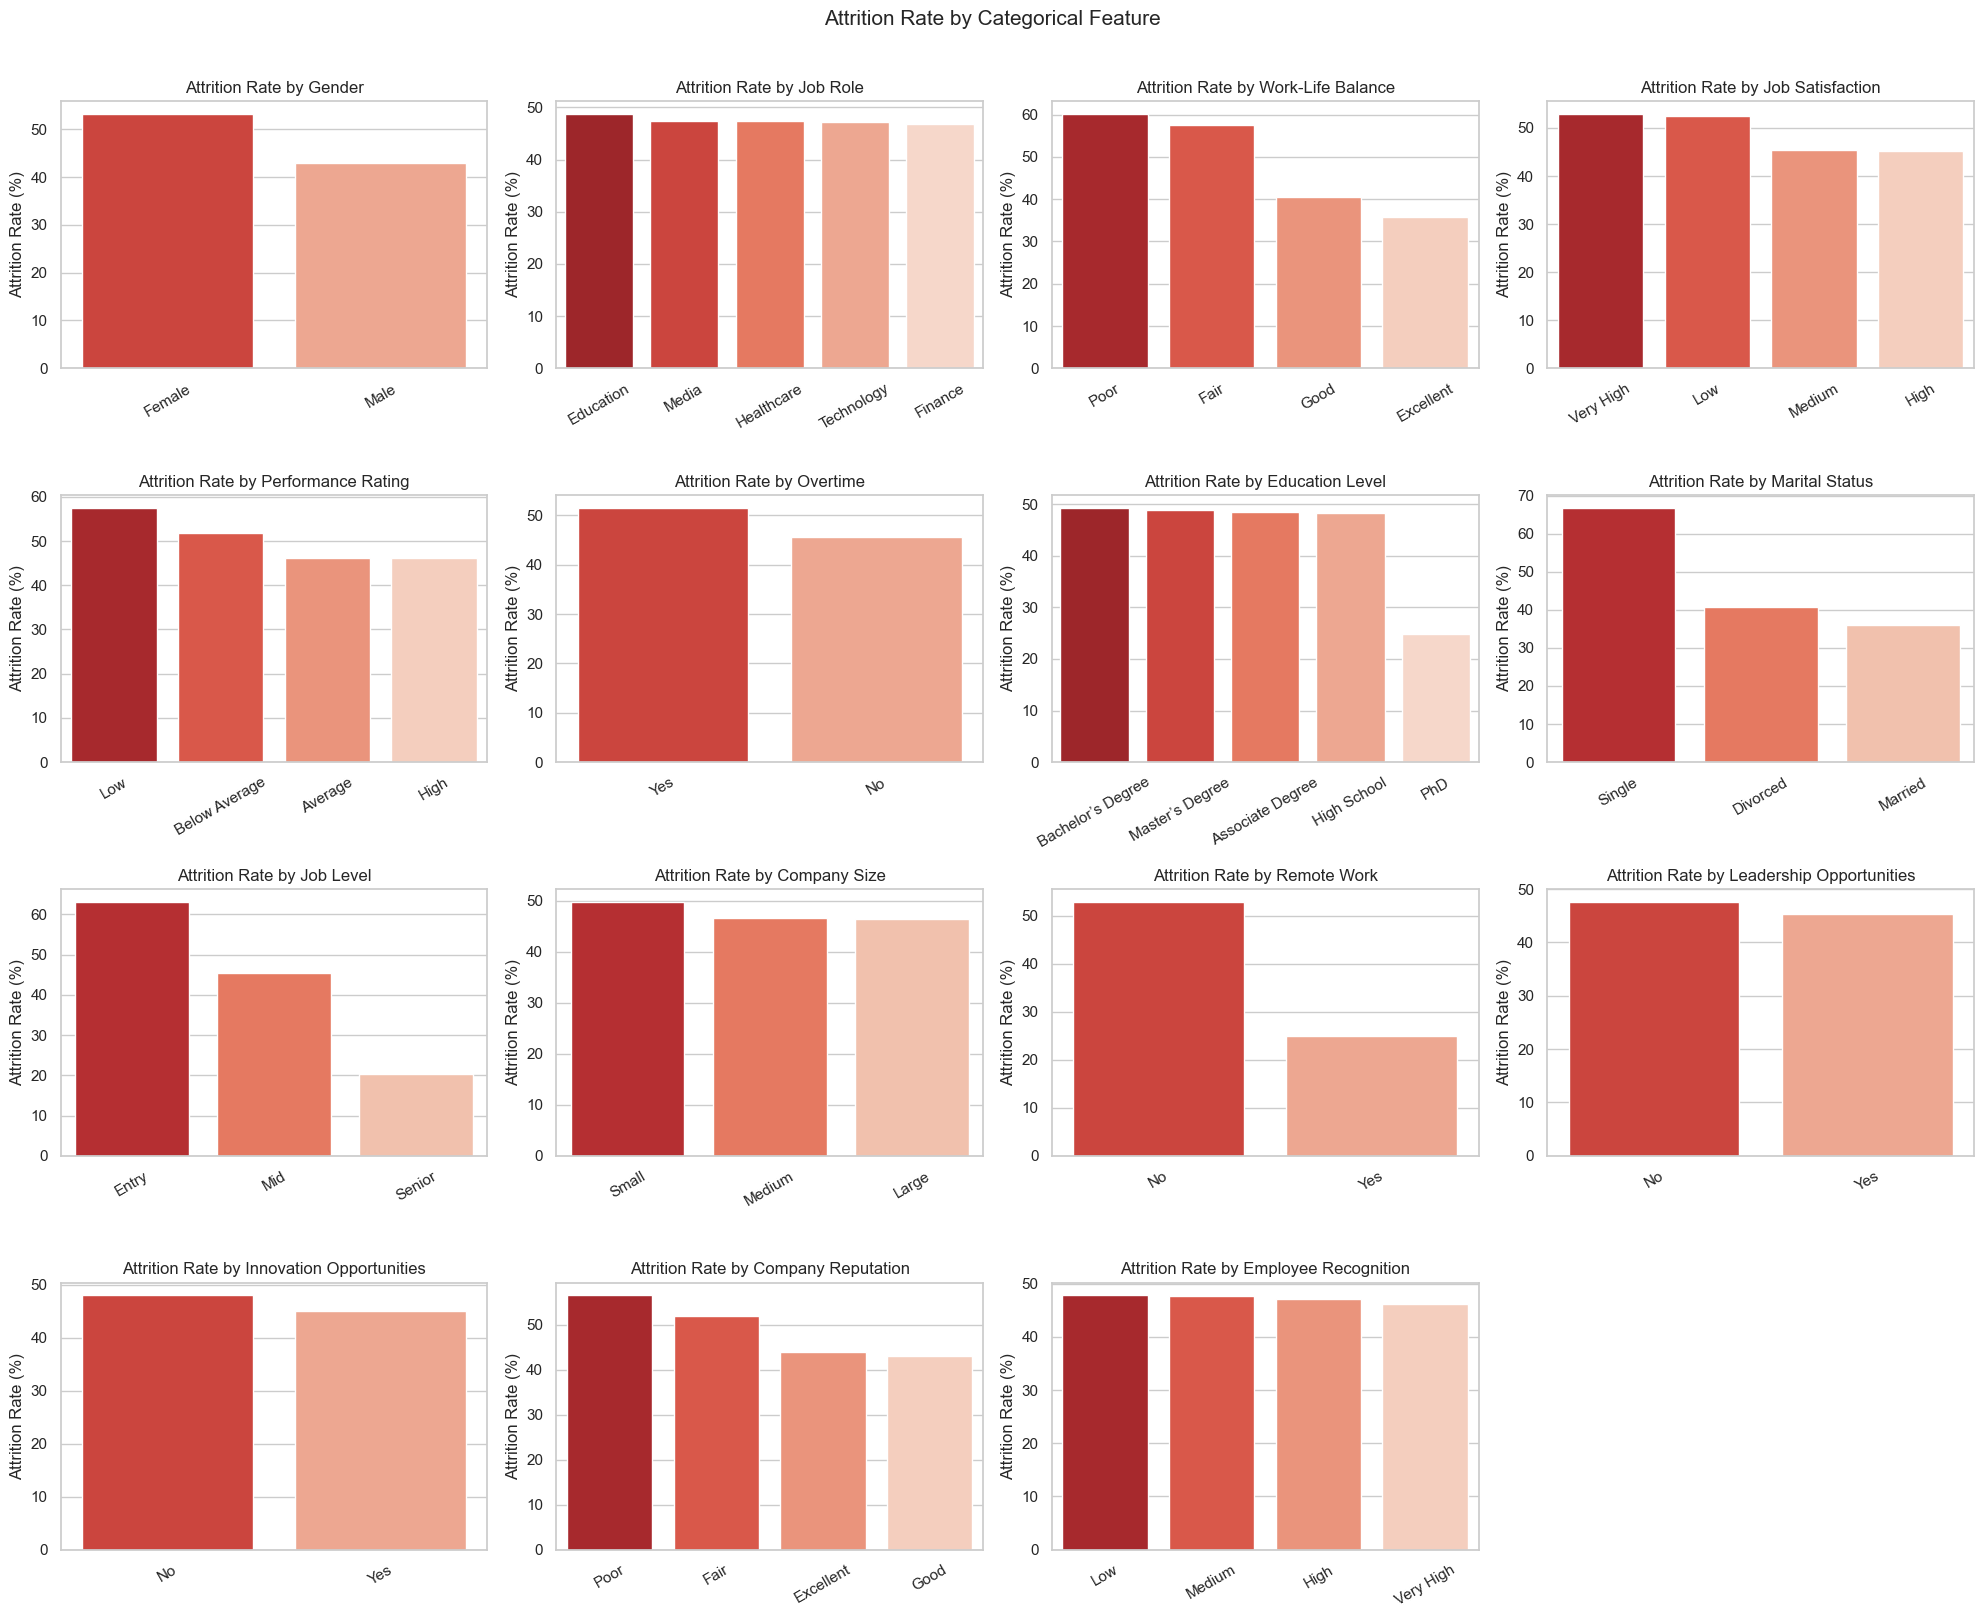

In [10]:
# ── 8. Categorical features overview ────────────────────────
cat_cols = train.select_dtypes(include="object").columns.tolist()
cat_cols.remove("Attrition")
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attrition_rate = (
        train.groupby(col)["Attrition"]
        .apply(lambda x: (x == "Left").mean() * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    attrition_rate.columns = [col, "Attrition Rate (%)"]
    sns.barplot(data=attrition_rate, x=col, y="Attrition Rate (%)",
                ax=axes[i], palette="Reds_r")
    axes[i].set_title(f"Attrition Rate by {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Attrition Rate by Categorical Feature", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("categorical_attrition_rates.png", dpi=150)
plt.show()

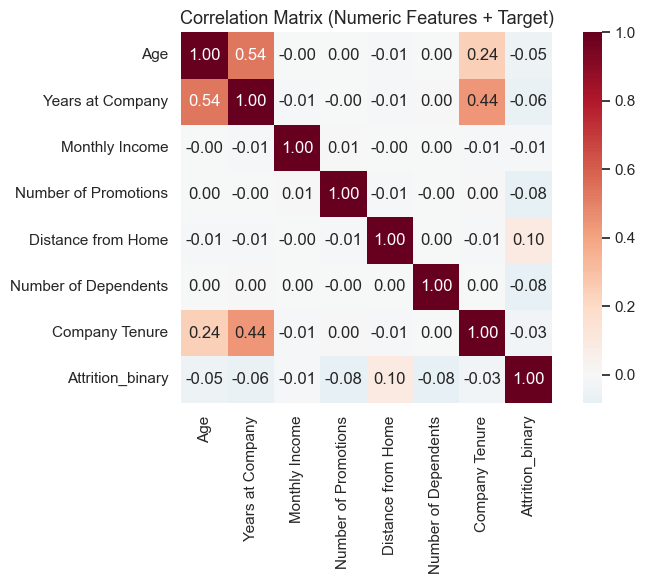

In [11]:
# ── 9. Correlation heatmap (numeric only) ───────────────────
corr_data = train[num_cols].copy()
corr_data["Attrition_binary"] = (train["Attrition"] == "Left").astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features + Target)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [12]:
# ── 10. Key findings summary ─────────────────────────────────
print("""
=== KEY FINDINGS FROM EDA ===

1. CLASS BALANCE
   - Check the Stayed vs Left % above.
   - If Left < 25%, dataset is imbalanced → we'll use SMOTE or class_weight in Step 3.

2. NUMERIC CORRELATIONS
   - Note which numeric features correlate most with Attrition_binary.
   - High positive correlation → that feature pushes people to leave.

3. CATEGORICAL PATTERNS
   - Look for categories with unusually high attrition bars — those are risk segments.
   - e.g., Overtime=Yes, Low Job Satisfaction, Poor Work-Life Balance are usually strong signals.

4. NO MISSING VALUES?
   - This dataset is often clean — if so, we skip imputation in Step 2.
   - But we still need encoding for categorical columns.

NEXT → Step 2: Data Cleaning + Feature Engineering
""")


=== KEY FINDINGS FROM EDA ===

1. CLASS BALANCE
   - Check the Stayed vs Left % above.
   - If Left < 25%, dataset is imbalanced → we'll use SMOTE or class_weight in Step 3.

2. NUMERIC CORRELATIONS
   - Note which numeric features correlate most with Attrition_binary.
   - High positive correlation → that feature pushes people to leave.

3. CATEGORICAL PATTERNS
   - Look for categories with unusually high attrition bars — those are risk segments.
   - e.g., Overtime=Yes, Low Job Satisfaction, Poor Work-Life Balance are usually strong signals.

4. NO MISSING VALUES?
   - This dataset is often clean — if so, we skip imputation in Step 2.
   - But we still need encoding for categorical columns.

NEXT → Step 2: Data Cleaning + Feature Engineering

